라이브러리 불러오기

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

옵션 설정하기

부동소수점 소수점 이하 6자리

In [2]:
pd.set_option('display.precision',6)

Data import

In [3]:
data_url = 'https://raw.githubusercontent.com/codingalzi/code-workout-datasci/refs/heads/master/data/'

In [4]:
housing=pd.read_csv(data_url+'housing.csv')

In [6]:
#tablecheck
housing.shape

(20640, 10)

In [7]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [8]:
housing.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [9]:
housing.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

In [10]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [11]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


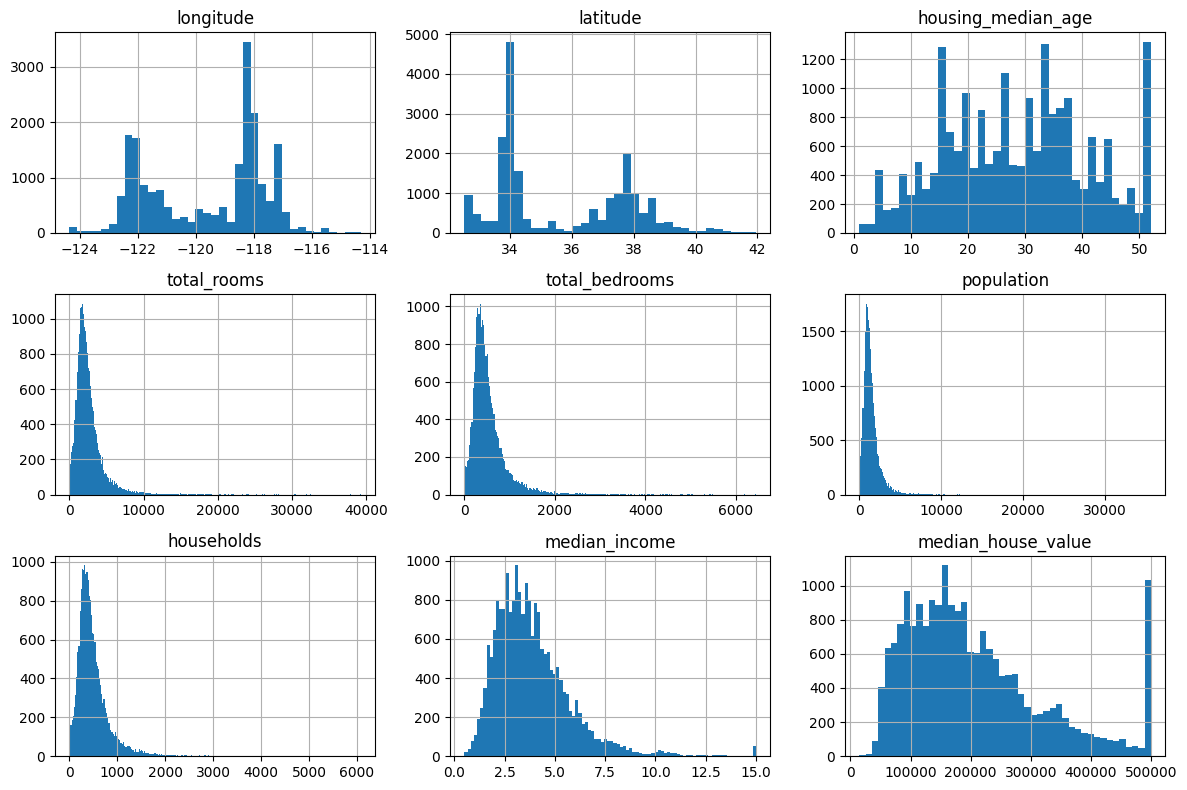

In [12]:
housing.hist(bins='auto', figsize=(12,8))
plt.tight_layout()
plt.show()

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

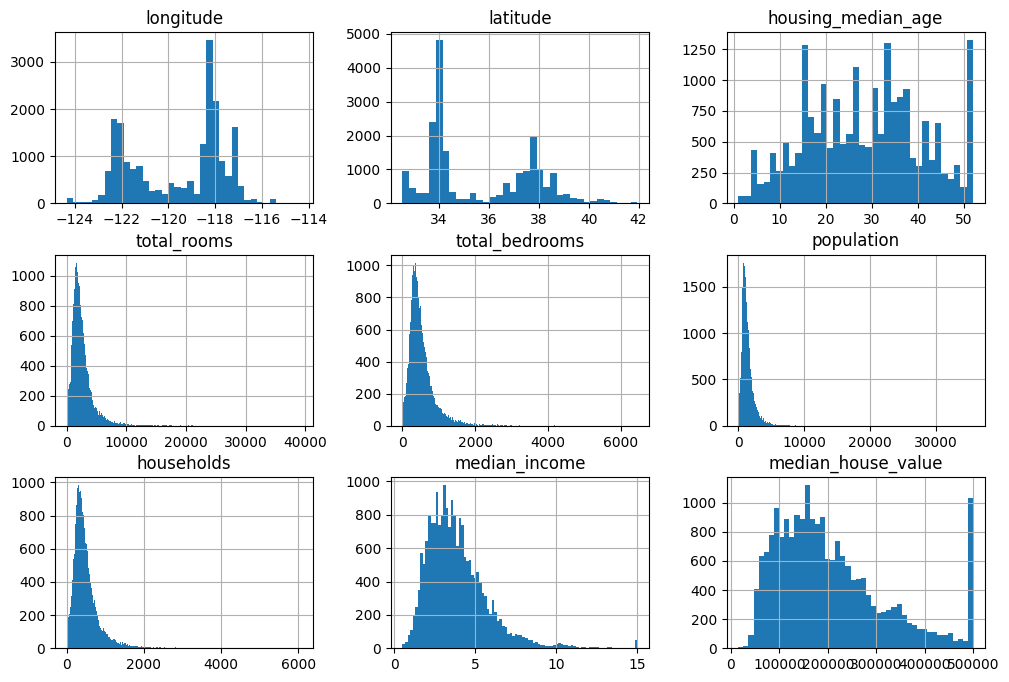

In [13]:
housing.hist(bins='auto', figsize=(12,8))

In [14]:
housing_test = housing.loc[:, ['total_rooms','median_income','median_house_value','housing_median_age','population','total_bedrooms']]

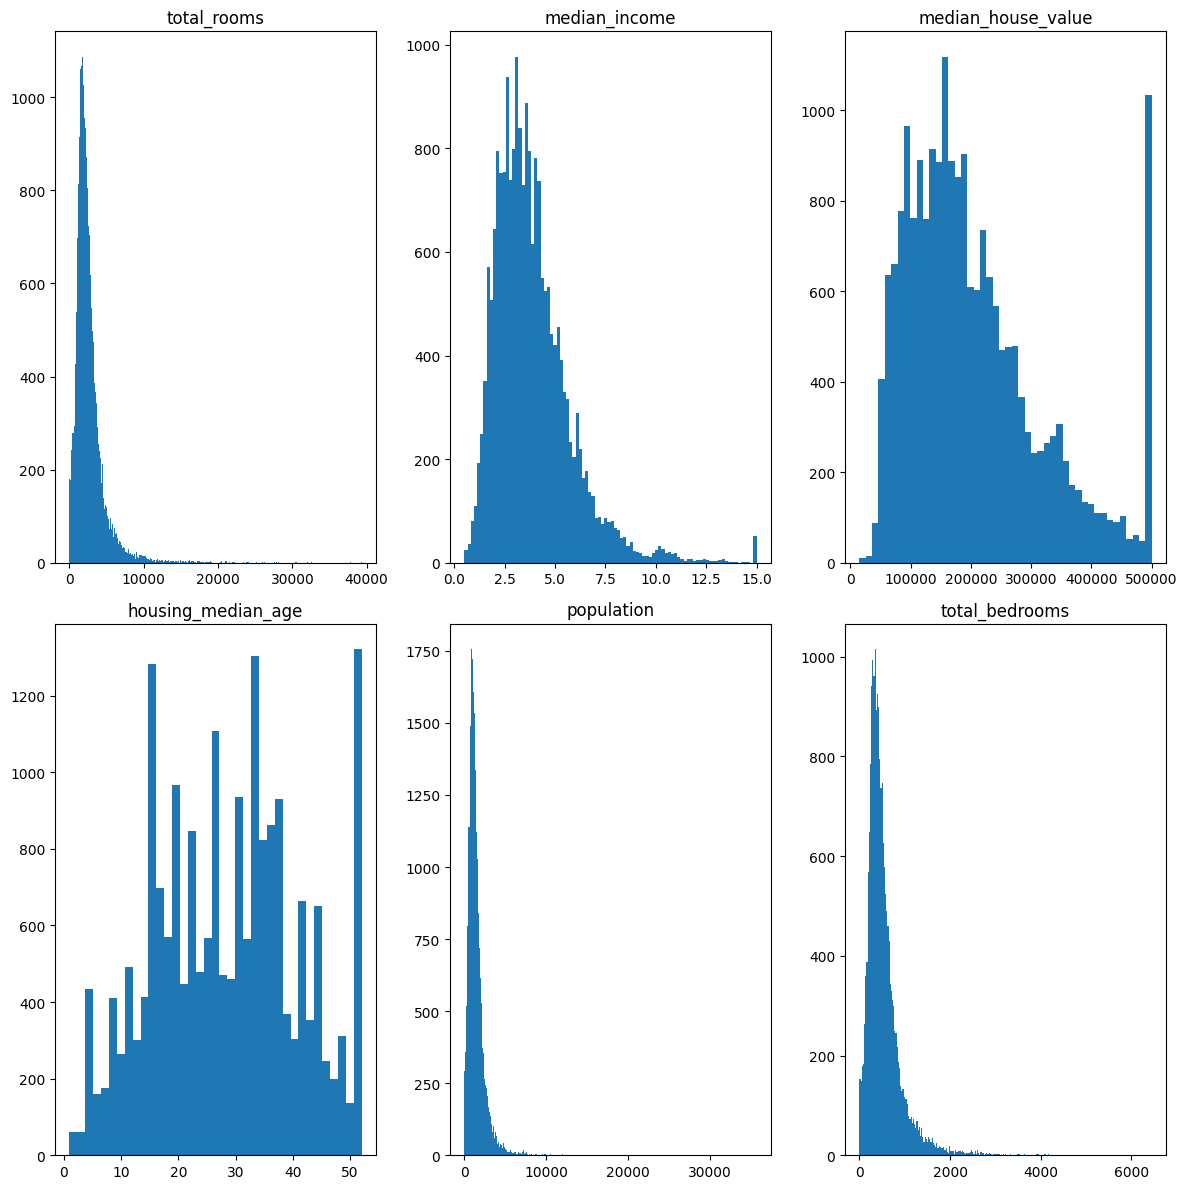

In [15]:
fig, axs = plt.subplots(2, 3, figsize=(12, 12))

# DataFrame의 각 열을 순서대로 subplot에 그리기
for col, ax in zip(housing_test.columns, axs.flat):
    ax.hist(housing_test[col], bins='auto')
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [18]:
ocean_proximity_values=housing["ocean_proximity"].unique()
ocean_proximity_values

<StringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str

In [19]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

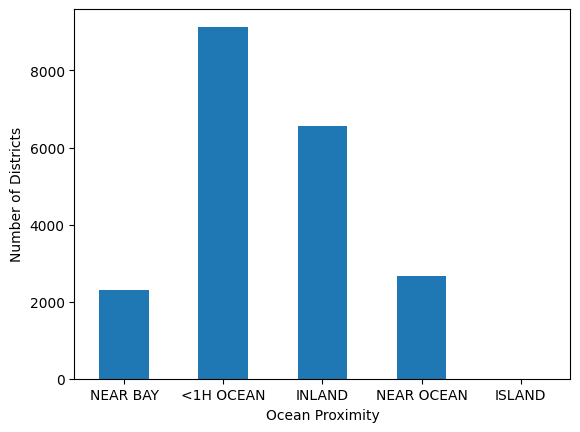

In [20]:
housing["ocean_proximity"].value_counts().loc[ocean_proximity_values].plot(kind='bar',rot=0)
plt.xlabel("Ocean Proximity")
plt.ylabel("Number of Districts")
plt.show()

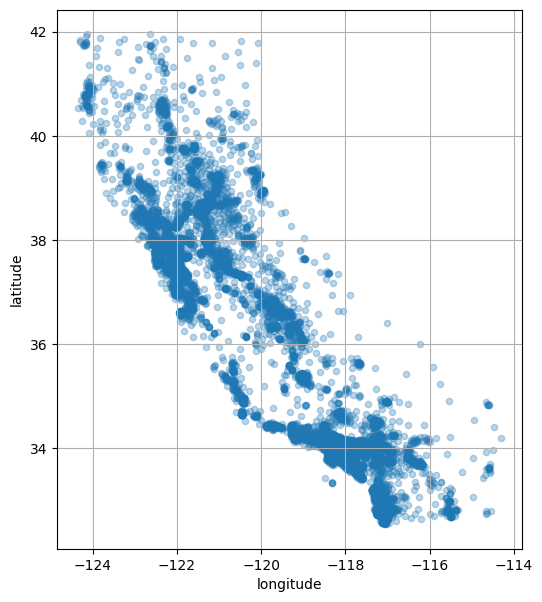

In [21]:
housing.plot(kind="scatter",
             x="longitude",
             y="latitude",
             grid=True,
             alpha=0.3,
             figsize=(6,7))
plt.show()

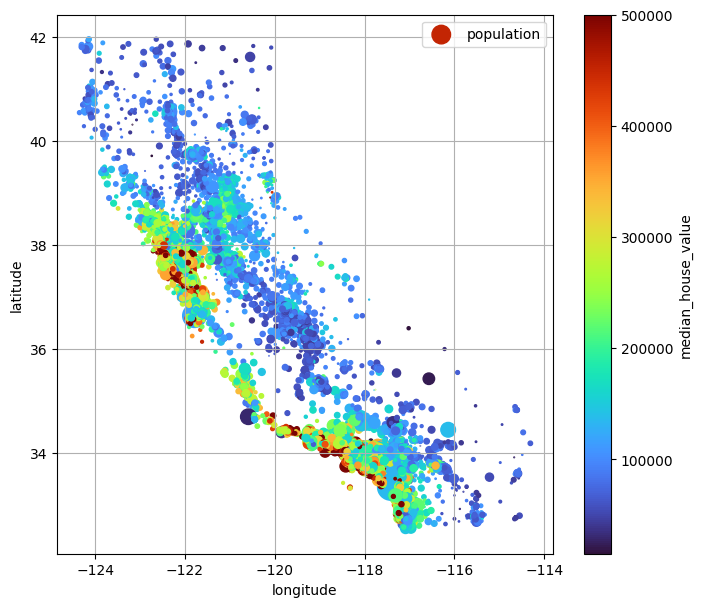

In [27]:
ax=housing.plot(kind="scatter", x="longitude", y="latitude", grid=True,
                s=housing["population"]/100, label="population",
                c="median_house_value",cmap="turbo",
                colorbar=True, figsize=(8,7))
#범례의 표기로 인해서 일반인들이 오해할 수 있음.
#그렇기 때문에 그래프에 대한 설명은 일부 필요함.
#예를들어 원의 크기가 인구수를 나타내고, 따뜻한 색으로 갈수록 집 값이 비싼 것을 의미한다.
#또한 위도 경도에 따른 위치로 점이 출력되고 있어 지역의 생김새를 유추하고,
#어느 부분의 날씨가 어떤지를 고려해 집값을 볼 수 있따.

In [8]:
housing.housing_median_age.value_counts()

housing_median_age
52.0    1273
36.0     862
35.0     824
16.0     771
17.0     698
34.0     689
26.0     619
33.0     615
18.0     570
25.0     566
32.0     565
37.0     537
15.0     512
19.0     502
27.0     488
24.0     478
30.0     476
28.0     471
20.0     465
29.0     461
31.0     458
23.0     448
21.0     446
14.0     412
22.0     399
38.0     394
39.0     369
42.0     368
44.0     356
43.0     353
40.0     304
13.0     302
41.0     296
45.0     294
10.0     264
11.0     254
46.0     245
5.0      244
12.0     238
8.0      206
9.0      205
47.0     198
4.0      191
48.0     177
7.0      175
6.0      160
50.0     136
49.0     134
3.0       62
2.0       58
51.0      48
1.0        4
Name: count, dtype: int64

In [6]:
housing.median_income.value_counts()

median_income
3.1250     49
15.0001    49
2.8750     46
4.1250     44
2.6250     44
           ..
1.4958      1
2.4695      1
2.3598      1
2.3661      1
2.0943      1
Name: count, Length: 12928, dtype: int64

In [7]:
housing.median_house_value.value_counts()

median_house_value
500001.0    965
137500.0    122
162500.0    117
112500.0    103
187500.0     93
           ... 
327900.0      1
438800.0      1
455500.0      1
200700.0      1
47000.0       1
Name: count, Length: 3842, dtype: int64